<a href="https://colab.research.google.com/github/fatima582/DI-BOOTCAMP/blob/main/ExercisesXP_Heart_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [5]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Exercise 1 - Exploratory Data Analysis

## 🌟 Exercice 1 : Analyse exploratoire des données

### Instructions
- Charger les données à partir des fichiers CSV
- Supprimer la colonne cible des données d'entraînement
- Séparer les données en groupes train/test
- Comprendre les données

In [17]:
# Extraire le zip du dataset dans un dossier de sortie
ZIP_PATH = '/content/Heart Disease Prediction Dataset.zip'
EXTRACT_DIR = 'heart_ds'
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Lister les fichiers CSV sous EXTRACT_DIR
csv_files = glob.glob(os.path.join(EXTRACT_DIR, '*.csv'))
if csv_files:
    csv_path = csv_files[0] # Supposons qu'il n'y ait qu'un seul CSV pertinent
    print(f"Fichier CSV trouvé: {csv_path}")
else:
    print("Aucun fichier CSV trouvé.")
    csv_path = None

# Charger le CSV dans un DataFrame nommé df
if csv_path:
    df = pd.read_csv(csv_path)
    # Clean column names by replacing spaces with underscores
    df.columns = [col.replace(' ', '_') for col in df.columns]
else:
    df = None
    print("Impossible de charger le DataFrame sans fichier CSV.")

# Inspecter df
if df is not None:
    print("\nPremières 5 lignes du DataFrame:")
    display(df.head())
    print("\nInformations générales du DataFrame:")
    df.info()
    print("\nStatistiques descriptives du DataFrame:")
    display(df.describe())

# Identifier la colonne cible
target = 'heart_disease' # La colonne cible pour la prédiction des maladies cardiaques est généralement 'target'

# Séparer les caractéristiques et la cible
if df is not None and target in df.columns:
    X = df.drop(columns=[target])
    y = df[target]
    print(f"\nCaractéristiques (X) shape: {X.shape}")
    print(f"Cible (y) shape: {y.shape}")
else:
    X = None
    y = None
    print("Impossible de séparer les caractéristiques et la cible. Le DataFrame est vide ou la colonne cible est manquante.")

# Diviser les données d'entraînement et de test avec stratification
if X is not None and y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    # Remap target labels 1 to 0 and 2 to 1 for binary classification models like XGBoost
    y_train = y_train.replace({1: 0, 2: 1})
    y_test = y_test.replace({1: 0, 2: 1})

    print(f"\nForme de X_train: {X_train.shape}")
    print(f"Forme de X_test: {X_test.shape}")
    print(f"Forme de y_train: {y_train.shape}")
    print(f"Forme de y_test: {y_test.shape}")
else:
    X_train, X_test, y_train, y_test = None, None, None, None
    print("Impossible de diviser les données d'entraînement et de test.")

Fichier CSV trouvé: heart_ds/dataset_heart.csv

Premières 5 lignes du DataFrame:


,age,sex_,chest_pain_type,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,max_heart_rate,exercise_induced_angina,oldpeak,ST_segment,major_vessels,thal,heart_disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1



Informations générales du DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex_                                  270 non-null    int64  
 2   chest_pain_type                       270 non-null    int64  
 3   resting_blood_pressure                270 non-null    int64  
 4   serum_cholestoral                     270 non-null    int64  
 5   fasting_blood_sugar                   270 non-null    int64  
 6   resting_electrocardiographic_results  270 non-null    int64  
 7   max_heart_rate                        270 non-null    int64  
 8   exercise_induced_angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST_segment                            270 non-nu

,age,sex_,chest_pain_type,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,max_heart_rate,exercise_induced_angina,oldpeak,ST_segment,major_vessels,thal,heart_disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000



Caractéristiques (X) shape: (270, 13)
Cible (y) shape: (270,)

Forme de X_train: (216, 13)
Forme de X_test: (54, 13)
Forme de y_train: (216,)
Forme de y_test: (54,)


### Basic visual checks

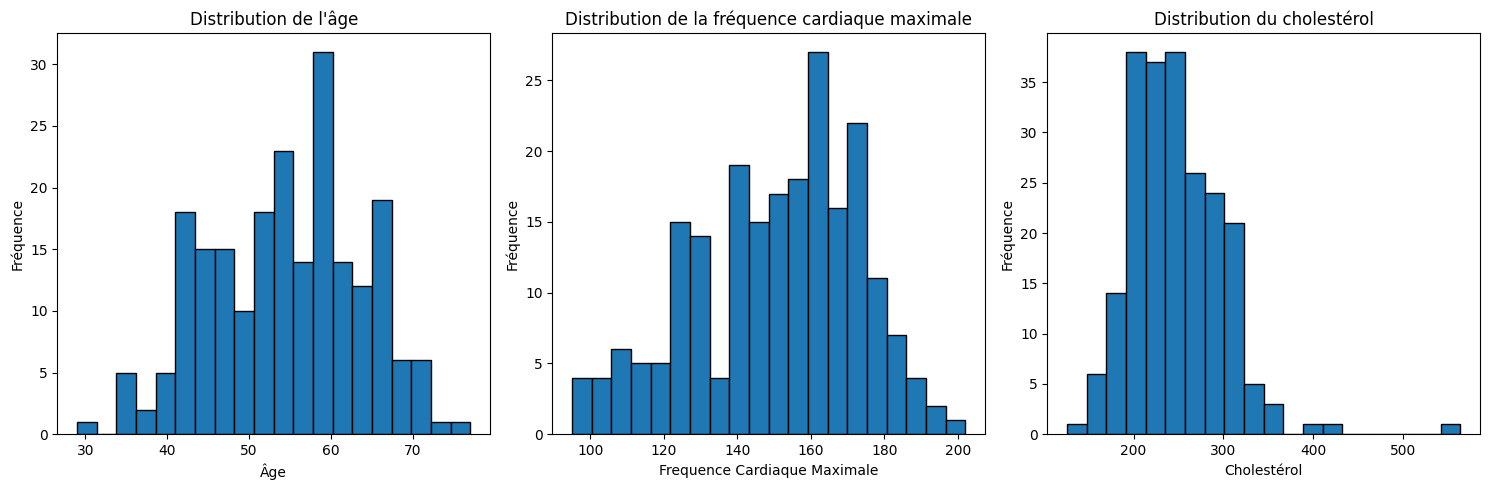

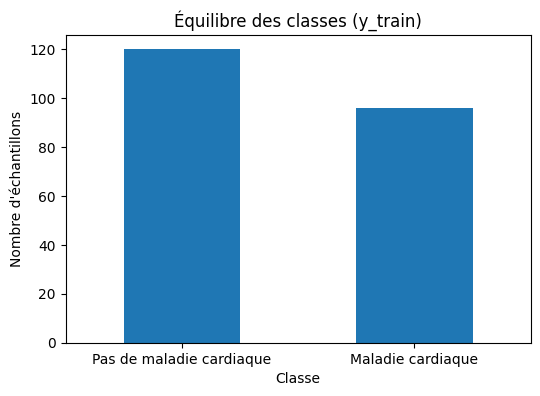

In [8]:
import matplotlib.pyplot as plt

# TODO: choisir quelques colonnes numériques et tracer les histogrammes
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(X_train['age'], bins=20, edgecolor='k')
plt.title('Distribution de l\'âge')
plt.xlabel('Âge')
plt.ylabel('Fréquence')

plt.subplot(1, 3, 2)
plt.hist(X_train['max_heart_rate'], bins=20, edgecolor='k') # Corrected column name
plt.title('Distribution de la fréquence cardiaque maximale')
plt.xlabel('Frequence Cardiaque Maximale')
plt.ylabel('Fréquence')

plt.subplot(1, 3, 3)
plt.hist(X_train['serum_cholestoral'], bins=20, edgecolor='k') # Corrected column name
plt.title('Distribution du cholestérol')
plt.xlabel('Cholestérol')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

# TODO: tracer l'équilibre des classes sous forme de diagramme à barres
plt.figure(figsize=(6, 4))
y_train.value_counts().plot(kind='bar')
plt.title('Équilibre des classes (y_train)')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'échantillons')
plt.xticks(ticks=[0, 1], labels=['Pas de maladie cardiaque', 'Maladie cardiaque'], rotation=0)
plt.show()

## Preprocessing pipeline

In [9]:
cat_cols = ['sex_', 'chest_pain_type', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'exercise_induced_angina', 'ST_segment', 'major_vessels', 'thal']
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'max_heart_rate', 'oldpeak']

# Build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

## Helper - evaluation function

In [10]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }
    print(f'{name} - Metrics:')
    for metric_name, value in metrics.items():
        print(f'  {metric_name}: {value:.4f}')

    # TODO: confusion matrix plot
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_ if hasattr(model, 'classes_') else None)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Matrice de confusion pour {name}')
    plt.show()

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        print(f'{name} - ROC AUC: {auc:.4f}')
        RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taux de faux positifs')
        plt.ylabel('Taux de vrais positifs')
        plt.title(f'Courbe ROC pour {name}')
        plt.show()
    else:
        print(f'{name} ne supporte pas predict_proba pour la courbe ROC.')

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

## 🌟 Exercice 2 : Régression logistique sans recherche par grille

### Instructions
Utilisez l'ensemble de données pour construire un modèle de régression logistique sans recourir à une recherche exhaustive. Divisez les données en ensembles d'entraînement et de test, puis entraînez le modèle de régression logistique et évaluez ses performances sur l'ensemble de test.

Logistic Regression (no grid search) - Metrics:
  accuracy: 0.8704
  precision: 0.9259
  recall: 0.8333
  f1: 0.8772


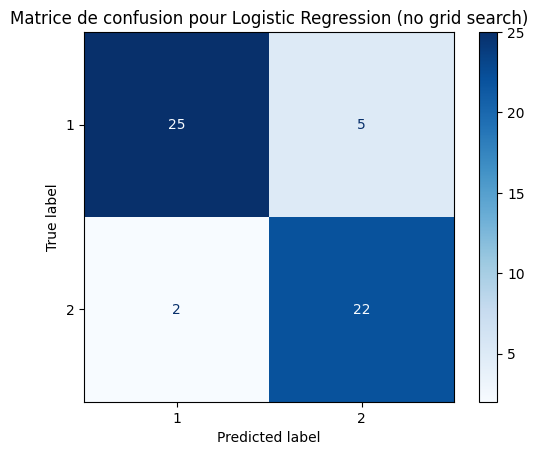

Logistic Regression (no grid search) - ROC AUC: 0.9139


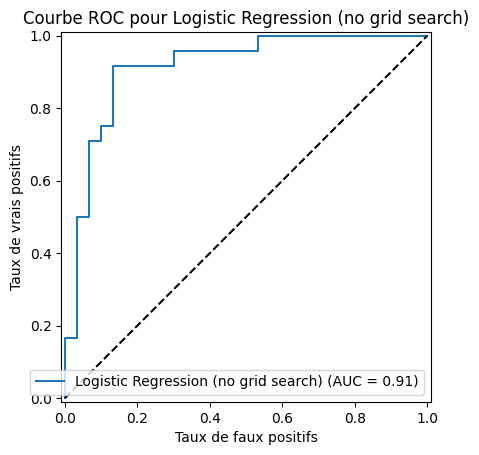

In [11]:
# Ensure preprocessor is defined with correct column names if not already
cat_cols = ['sex_', 'chest_pain_type', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'exercise_induced_angina', 'ST_segment', 'major_vessels', 'thal']
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'max_heart_rate', 'oldpeak']

pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline(steps=[('preprocessor', pre), ('lr', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('Logistic Regression (no grid search)', pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

## 🌟 Exercice 3 : Régression logistique avec recherche par grille

### Instructions
Construisez un modèle de régression logistique à l'aide de l'ensemble de données, mais cette fois-ci, utilisez GridSearchCV pour optimiser les hyperparamètres tels que C et la pénalité.

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
LR grid - Metrics:
  accuracy: 0.8704
  precision: 0.9259
  recall: 0.8333
  f1: 0.8772


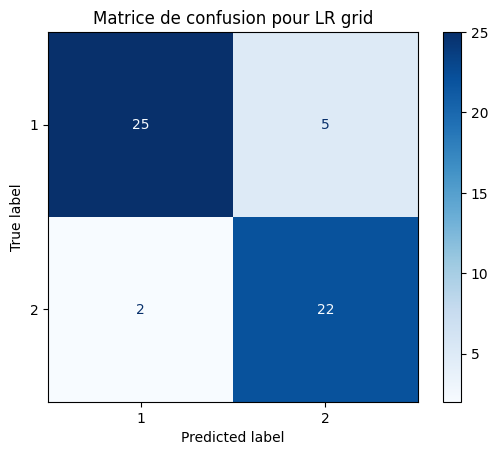

LR grid - ROC AUC: 0.9250


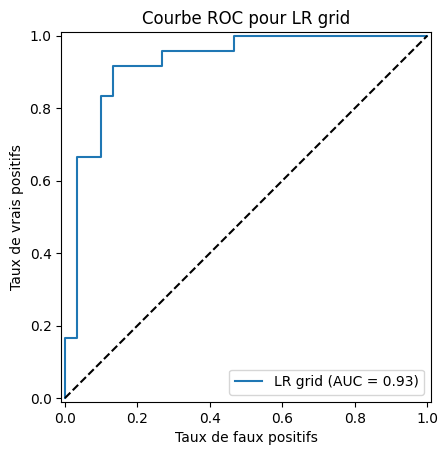

In [12]:
# Ensure preprocessor is defined with correct column names if not already
cat_cols = ['sex_', 'chest_pain_type', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'exercise_induced_angina', 'ST_segment', 'major_vessels', 'thal']
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'max_heart_rate', 'oldpeak']

pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline(steps=[('preprocessor', pre), ('lr', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

## 🌟 Exercice 4 : SVM sans recherche par grille

### Instructions
Entraînez un classificateur SVM (Support Vector Machine) sur l'ensemble de données sans utiliser de recherche par grille. Choisissez un noyau approprié et définissez manuellement les hyperparamètres.

SVM (no grid search) - Metrics:
  accuracy: 0.8519
  precision: 0.9231
  recall: 0.8000
  f1: 0.8571


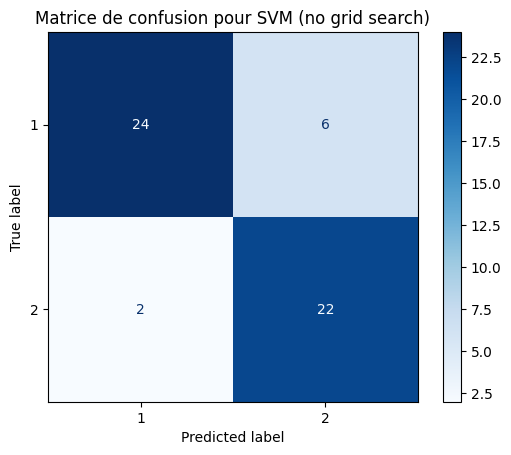

SVM (no grid search) - ROC AUC: 0.9111


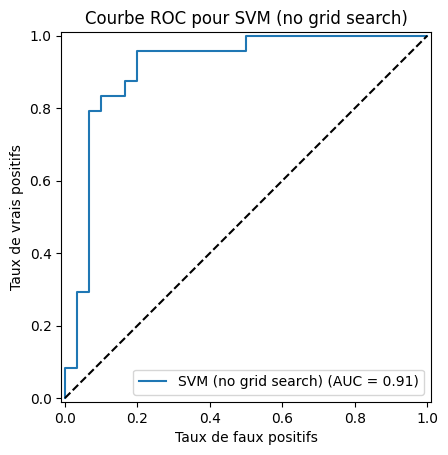

In [13]:
# Ensure preprocessor is defined with correct column names if not already
cat_cols = ['sex_', 'chest_pain_type', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'exercise_induced_angina', 'ST_segment', 'major_vessels', 'thal']
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'max_heart_rate', 'oldpeak']

pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline(steps=[('preprocessor', pre), ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE, probability=True))])

# Fit on training data
pipe_svm.fit(X_train, y_train)

# Evaluate with eval_and_report
svm_no_metrics = eval_and_report('SVM (no grid search)', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

## 🌟 Exercice 5 : SVM avec recherche par grille

### Instructions
Implémentez un classificateur SVM sur l'ensemble de données avec GridSearchCV pour trouver la meilleure combinaison des hyperparamètres C, noyau et gamma.

Best params: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
SVM grid - Metrics:
  accuracy: 0.8519
  precision: 0.8929
  recall: 0.8333
  f1: 0.8621


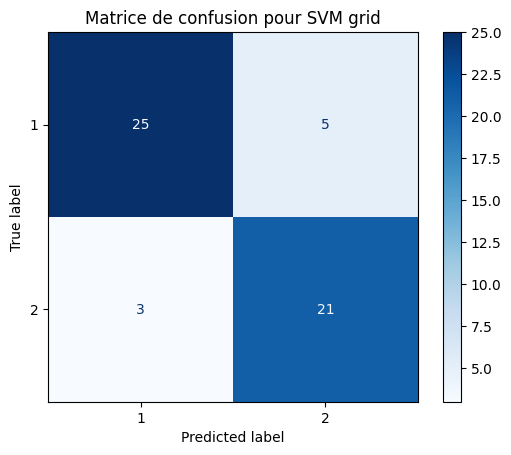

SVM grid - ROC AUC: 0.9181


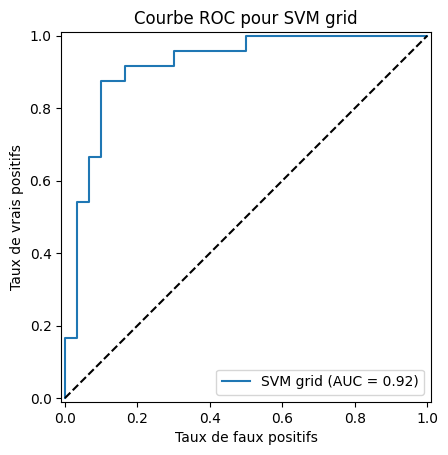

In [14]:
# Ensure preprocessor is defined with correct column names if not already
cat_cols = ['sex_', 'chest_pain_type', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'exercise_induced_angina', 'ST_segment', 'major_vessels', 'thal']
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'max_heart_rate', 'oldpeak']

pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline(steps=[('preprocessor', pre), ('svc', SVC(random_state=RANDOM_STATE, probability=True))])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svc__kernel': ['rbf', 'linear'],
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 'auto'],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

## 🌟 Exercice 6 : XGBoost sans recherche par grille

### Instructions
Utilisez l'ensemble de données pour entraîner un classificateur XGBoost sans optimisation des hyperparamètres. Définissez les hyperparamètres manuellement et justifiez vos choix.

XGBoost (no grid search) - Metrics:
  accuracy: 0.8333
  precision: 0.8000
  recall: 0.8333
  f1: 0.8163


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:38:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


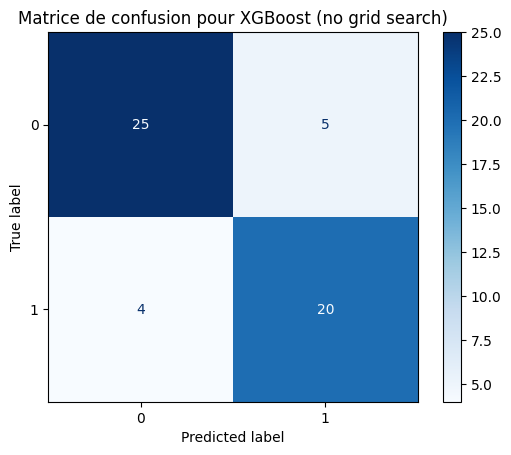

XGBoost (no grid search) - ROC AUC: 0.8458


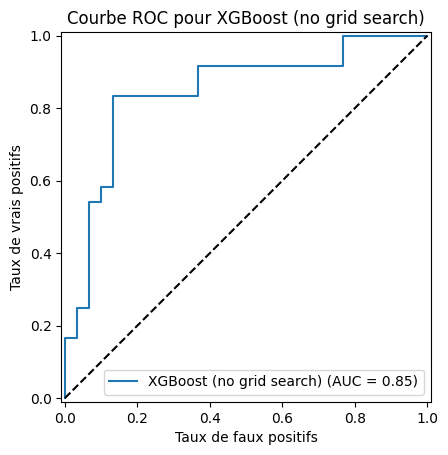

In [18]:
# Ensure preprocessor is defined with correct column names if not already
cat_cols = ['sex_', 'chest_pain_type', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'exercise_induced_angina', 'ST_segment', 'major_vessels', 'thal']
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'max_heart_rate', 'oldpeak']

pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        use_label_encoder=False,
        random_state=RANDOM_STATE))
])

# Fit on training data
pipe_xgb.fit(X_train, y_train)

# Evaluate with eval_and_report
xgb_no_metrics = eval_and_report('XGBoost (no grid search)', pipe_xgb, X_test, y_test)

## Exercise 7 - XGBoost with Grid Search

## 🌟 Exercice 7 : XGBoost avec recherche par grille

### Instructions
Entraînez un classificateur XGBoost sur l'ensemble de données en utilisant GridSearchCV pour optimiser les hyperparamètres tels que learning_rate, n_estimators, max_depth, etc.

Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.3, 'xgb__max_depth': 7, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
XGB grid - Metrics:
  accuracy: 0.8333
  precision: 0.8000
  recall: 0.8333
  f1: 0.8163


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:39:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


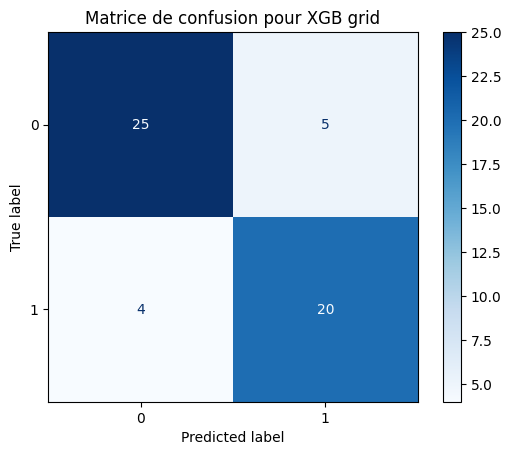

XGB grid - ROC AUC: 0.8639


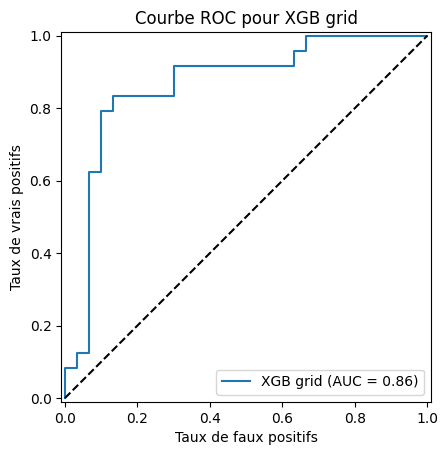

In [19]:
# Ensure preprocessor is defined with correct column names if not already
cat_cols = ['sex_', 'chest_pain_type', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'exercise_induced_angina', 'ST_segment', 'major_vessels', 'thal']
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'max_heart_rate', 'oldpeak']

pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__learning_rate': [0.01, 0.1, 0.3],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print('Best params:', grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)

## Compare models

## ⚠️ Soumettre votre travail :
Lorsque vous aurez terminé :

📝 Soumettez votre travail sur la plateforme DI Learning en collant un lien Google Colab public vers votre notebook terminé.
(Facultatif) Vous pouvez également enregistrer le carnet🗒️ sur votre propre dépôt GitHub si vous souhaitez conserver tous vos exercices au même endroit.
Comment enregistrer votre Colab sur GitHub (facultatif) :

In [21]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
summary = {}
summary['LR no grid'] = lr_no_gs_metrics
summary['LR grid'] = lr_gs_metrics
summary['SVM no grid'] = svm_no_metrics
summary['SVM grid'] = svm_gs_metrics
summary['XGBoost no grid'] = xgb_no_metrics
summary['XGBoost grid'] = xgb_gs_metrics

comparison_df = pd.DataFrame.from_dict(summary, orient='index')
comparison_df.index.name = 'Model'
print("Tableau comparatif des métriques des modèles:")
display(comparison_df)

Tableau comparatif des métriques des modèles:


,accuracy,precision,recall,f1
Model,,,,
LR no grid,0.870370,0.925926,0.833333,0.877193
LR grid,0.870370,0.925926,0.833333,0.877193
SVM no grid,0.851852,0.923077,0.800000,0.857143
SVM grid,0.851852,0.892857,0.833333,0.862069
XGBoost no grid,0.833333,0.800000,0.833333,0.816327
XGBoost grid,0.833333,0.800000,0.833333,0.816327
